<a href="https://colab.research.google.com/github/kamalahmadov474/Machine_Learning/blob/main/Predicting_Victory_Conditions_in_Chess_Based_on_Time_Control_and_Player_Metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# For uploading CSV file from your local system
from google.colab import files
uploaded = files.upload()

# Load the CSV file
filename = next(iter(uploaded))
df = pd.read_csv(filename)


Saving games.csv to games (1).csv


In [3]:
# Split increment_code into base time and increment time (both in seconds)
df[['base_sec', 'increment_sec']] = df['increment_code'].str.split('+', expand=True).astype(int)

# Create total initial time (as rough estimate): base + 40 * increment
df['estimated_total_time'] = df['base_sec'] + df['increment_sec'] * 40

In [5]:
# Select features and drop rows with missing values
features = ['base_sec', 'increment_sec', 'estimated_total_time',
            'white_rating', 'black_rating', 'opening_ply', 'turns']

df_ml = df[features + ['victory_status']].dropna()

X = df_ml[features]
y = df_ml['victory_status']


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode target labels (mate = 0, resign = 1, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:45:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
# Make predictions
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# Evaluation function
def evaluate(model_name, y_true, y_pred):
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    print(confusion_matrix(y_true, y_pred))
    print("\n")

# Evaluate all models
evaluate("Logistic Regression", y_test, lr_preds)
evaluate("Random Forest", y_test, rf_preds)
evaluate("XGBoost", y_test, xgb_preds)


=== Logistic Regression ===
              precision    recall  f1-score   support

        draw       0.00      0.00      0.00       181
        mate       0.45      0.19      0.27      1295
   outoftime       0.00      0.00      0.00       336
      resign       0.59      0.93      0.72      2200

    accuracy                           0.57      4012
   macro avg       0.26      0.28      0.25      4012
weighted avg       0.47      0.57      0.48      4012

[[   0   62    0  119]
 [   1  249    0 1045]
 [   0   79    0  257]
 [   0  161    0 2039]]


=== Random Forest ===
              precision    recall  f1-score   support

        draw       0.59      0.11      0.19       181
        mate       0.50      0.40      0.45      1295
   outoftime       0.50      0.15      0.23       336
      resign       0.63      0.82      0.72      2200

    accuracy                           0.60      4012
   macro avg       0.56      0.37      0.40      4012
weighted avg       0.58      0.60      0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


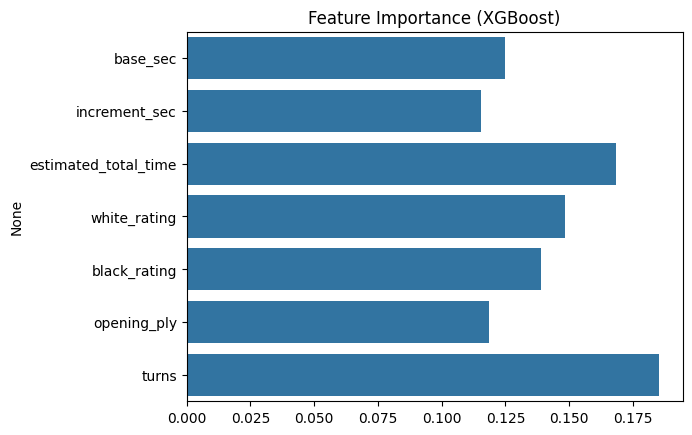

In [10]:
importance = xgb_model.feature_importances_
sns.barplot(x=importance, y=X.columns)
plt.title("Feature Importance (XGBoost)")
plt.show()
